(P:lab71)=
# Sobel and Canny detectors

The image used in this lab and the two next ones is {download}`L.png`.

* Display the image gradients with the Sobel detector (`skimage.filters.sobel`).

* Apply a threshold on the obtained image to perform an edge detection.
  What is the influence of the threshold on the result?

* Find the optimal threshold, _i.e._ the one which gives most of the edges of the object while keeping precise locations of the edges.

* What is the relationship between Sobel and Canny detectors?

* Display the edges detected by Canny detector (`skimage.feature.canny`).

* Discuss the influence of the main parameters of the method,
  namely the size of the Gaussian filter and the two thresholds.

It is sometimes interesting to compare the studied methods in terms of computation time.
The computation time can be obtained by calculating the difference
between the time $t_2$ measured after executing the method and the time $t_1$ measured before its execution.
For that, you can use the function `time.time` which gives the number of seconds elapsed since January 1, 1970.

* What is the fastest method between Sobel and Canny?

  * * *

**📌 Commentaires pour les intervenants**

- TP est assez long, car il faut tester et comprendre les différents paramètres des méthodes.
  Certains étudiants vont donc prendre le temps de comprendre et tester ces paramètres, mais il ne finiront pas le TP.
  D'autres survoleront les questions et finiront le TP.
  Je préfère que le étudiants se posent des questions, quitte à ne pas terminer le TP.

- Ce TP préfigure le projet : autonomie plus importante, étude de l'influence des paramètres, etc.

The objectives of this exercise are to:
* detect edges using Sobel and Canny detectors
* understand the influence of the parameters of these methods
* compare these methods in terms of computation time

In [1]:
from skimage.io import imread
from skimage.filters import sobel, sobel_h, sobel_v
from skimage.feature import canny

from matplotlib.pyplot import figure, imshow, title, subplot, plot, show, plot, xlabel, ylabel, axis

import time

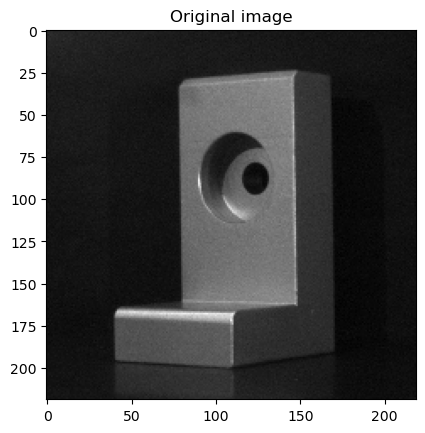

In [ ]:
x = imread("L.png")
figure
imshow(x, cmap="gray")
title("Original image")
show()

:::{warning}
Always show the original image, even if is is not explicit!
It helps you to understand the results of your image processing implementation.
:::

### Sobel detector

The Sobel detector performs a convolution of the image by two filters,
each getting the gradient of the image in the two dimensions.
These two gradients can be merged to result in the right image (how are they merged?).

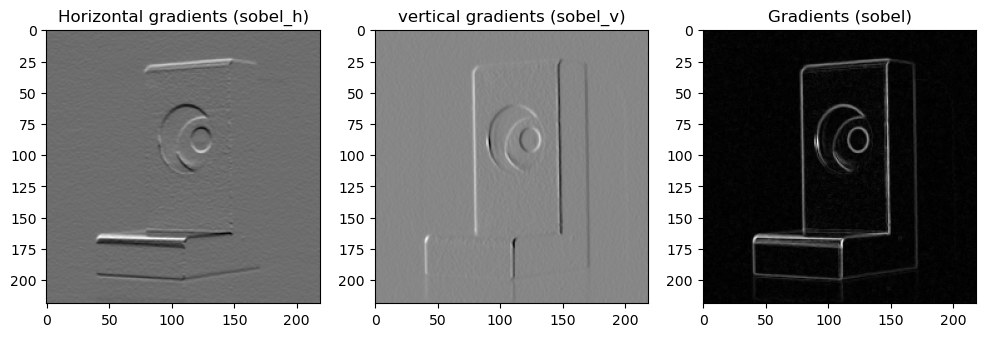

In [6]:
figure(figsize=(12,9))

subplot(1,3,1)
imshow(sobel_h(x), cmap="gray")
title("Horizontal gradients (sobel_h)")

subplot(1,3,2)
imshow(sobel_v(x), cmap="gray")
title("vertical gradients (sobel_v)")

subplot(1,3,3)
imshow(sobel(x), cmap="gray")
title("Gradients (sobel)")

show()

The gradient image can be thresholded to identify major contours.
The results for three threshold values are given below.

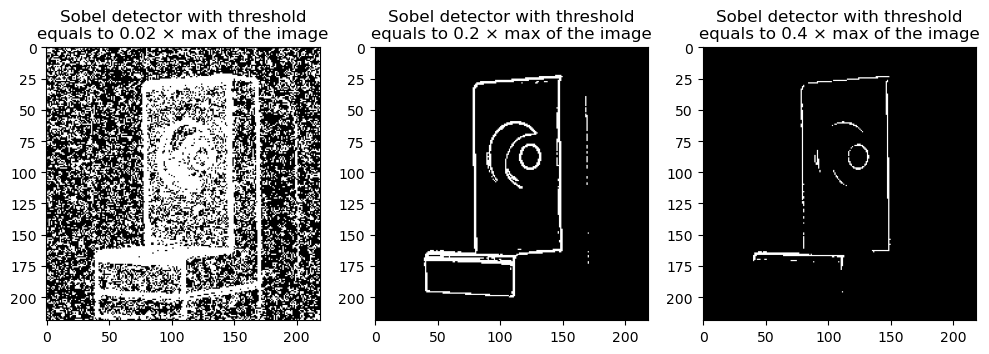

In [8]:
y = sobel(x)
seuils = [.02, .20, .40]

figure(figsize=(12,9))
for i, seuil in enumerate(seuils):
    z = y > seuil*y.max()
    subplot(1,3,i+1)
    imshow(z, cmap="gray")
    title(f"Sobel detector with threshold\nequals to {seuil} × max of the image")

* We note that the higher the threshold, the fewer contours detected (there are fewer white pixels).
  This is because fewer pixels have a gradient greater than the threshold,
  and therefore will be considered as edges.
  
* If the threshold is too low, then edges are detected almost everywhere.
  In particular, the background of the image being (slightly) noisy, edges can be detected there.
  
* On the contrary, if the threshold is too high, then there are a lot of non-detections
  even though there are hardly any false alarms left.
  
* In addition, even by setting the threshold high enough, some edges are still wide:
  they have a width of several pixels, which implies that the edge, although detected, is not positioned with precision.

### Canny detector

Canny detector is more complex than a simple filtering.
It includes in particular a thresholding by hysteresis, _i.e._ a decision based on two thresholds $T_{low}$ and $T_{high}$:
* the pixels of intensity lower than $T_{low}$ will not be considered as edges,
* pixels with an intensity greater than $T_{high}$ will be considered as edges,
* pixels with an intensity between $T_{low}$ and $T_{high}$ will be detected as edges
  if and only if they are neighbors of pixels whic are edges.

#### Influence of the Gaussian standard deviation (`sigma`)

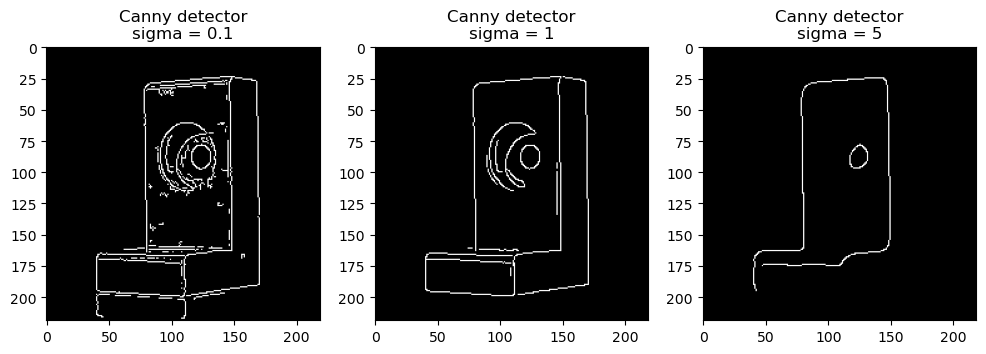

In [9]:
sigs = [0.1, 1, 5]
figure(figsize=(12,9))
for i, sig in enumerate(sigs):
    z = canny(x, sigma=sig)
    subplot(1,3,i+1)
    imshow(z, cmap="gray")
    title(f"Canny detector\nsigma = {sig}")

We observe that if `sigma` increases, then the number of edges detected is lower.
This can be explained by the fact that the first step of the Canny detector is a filtering of the image by a Gaussian
(with standard deviation `sigma`) to reduce the noise.
In consequence, the image is more blurry and therefore the edges are less marked: they are therefore more difficult to detect.

#### Influence of $T_{low}$ (`low_threshold`)

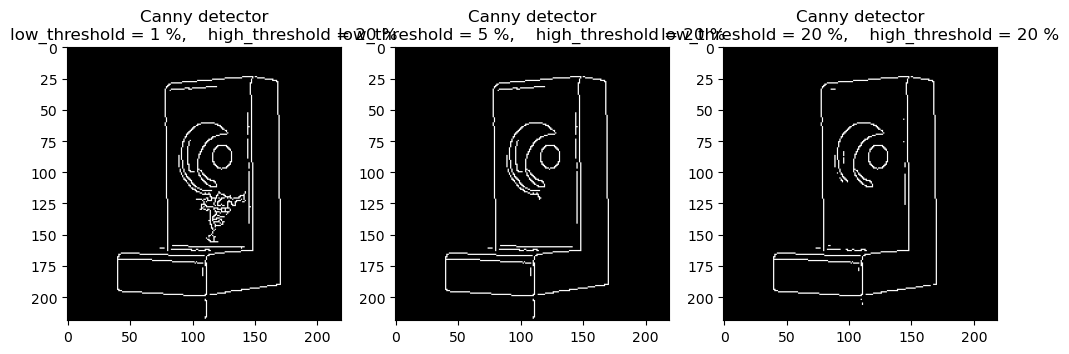

In [10]:
seuils = [0.01, 0.05, 0.2]
seuil_haut = 0.2
figure(figsize=(12,9))
for i, seuil_bas in enumerate(seuils):
    z = canny(x, low_threshold=seuil_bas*x.max(), high_threshold=seuil_haut*x.max())
    subplot(1,3,i+1)
    imshow(z, cmap="gray")
    title(f"Canny detector\nlow_threshold = {seuil_bas*100:.0f} %,    high_threshold = {seuil_haut*100:.0f} %")

When the lower threshold increases, the number of detected edges decreases,
since there are fewer pixels whose gradient value is greater than the lower threshold.

#### Influence of $T_{high}$ (`high_threshold`)

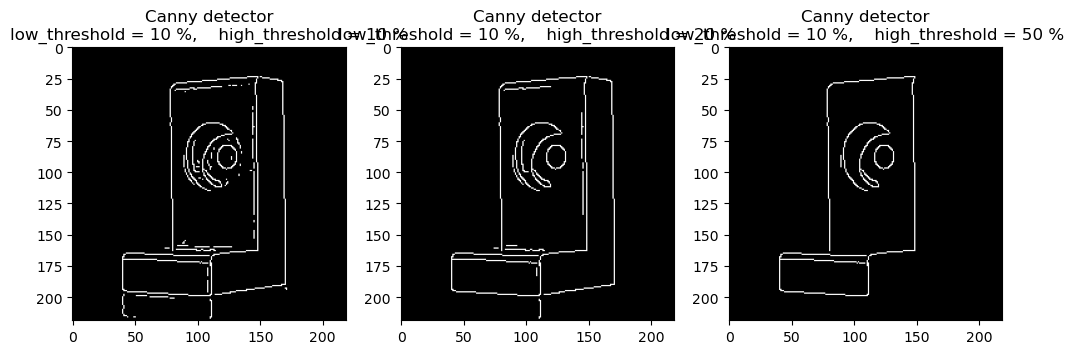

In [11]:
seuils = [0.1, 0.2, 0.5]
seuil_bas = 0.1
figure(figsize=(12,9))
for i, seuil_haut in enumerate(seuils):
    z = canny(x, low_threshold=seuil_bas*x.max(), high_threshold=seuil_haut*x.max())
    subplot(1,3,i+1)
    imshow(z, cmap="gray")
    title(f"Canny detector\nlow_threshold = {seuil_bas*100:.0f} %,    high_threshold = {seuil_haut*100:.0f} %")

As before, the more the higher threshold increases, the fewer edges are detected.

In conclusion, we observe that the number of detected edges decreases with the value of the thresholds, as for the Sobel detector.
Besides, the Canny detector produces fine and mostly continuous contours: detection is therefore clearer and more precise.

### Comparison of the two methods in terms of computation time

One of the steps of the Canny detector is to apply a Sobel filter.
So the Canny detector is expected to be slower than the Sobel detector.
We measure the time required for each method to detect the edges of the image.

For practical reasons, depending especially on the computer used for the test,
the results are not perfectly reproducible:
if you run the comparison twice, the computation times will differ slightly.
Therefore, it is advised to measure the computation times over many simulations (100 below).

In [13]:
I = 100           # Number of simulations
total_sobel = 0   # Total time for the I simulations for the Sobel detector
total_canny = 0   # Total time for the I simulations for the Canny detector

for i in range(I):
    
    # Computation time for the Sobel detector
    tic = time.time()
    y = sobel(x)
    z = y > 0.5*y.max() # Don't forget to take thresholding into account!
    tac = time.time()
    time_sobel = tac-tic
    total_sobel += time_sobel
    
    # Computation time for the Canny detector
    tic = time.time()
    z = canny(x)
    tac = time.time()
    time_canny = tac-tic
    total_canny += time_canny
    
    # Display the computation time of the two methods (for the first 10 simulations only)
    if i<10:
        print(f"Sobel : {time_sobel*1e3:.3f} ms     Canny : {time_canny*1e3:.3f} ms")
    elif i==10:
        print("etc.")
    
print(f"\nCanny detector is about {total_canny/total_sobel:.0f} times slower than Sobel detector.")

Sobel : 0.972 ms     Canny : 1.513 ms
Sobel : 0.633 ms     Canny : 1.377 ms
Sobel : 0.544 ms     Canny : 1.207 ms
Sobel : 0.466 ms     Canny : 1.213 ms
Sobel : 0.476 ms     Canny : 1.383 ms
Sobel : 0.564 ms     Canny : 1.358 ms
Sobel : 0.601 ms     Canny : 1.533 ms
Sobel : 0.592 ms     Canny : 1.357 ms
Sobel : 0.615 ms     Canny : 1.515 ms
Sobel : 0.692 ms     Canny : 1.256 ms
etc.

Canny detector is about 2 times slower than Sobel detector.


We were right: Canny detector is slower than Sobel detector.
However, the computation time remains very acceptable for images of classic size (around 1.5 ms on my computer),
so the time difference between the two methods is not detrimental in the majority of applications.